# 📈 회귀(Regression) 모델 — 보스턴 집값 예측

정답이 **숫자(연속값)** 인 문제를 푸는 **회귀 모델**을 배운다.
(분류 = 카테고리를 맞힌다 ↔ **회귀 = 값을 맞힌다**)

> ⚙️ **아래 코드는 수업 때 작성한 내용 그대로이며, 이해를 돕는 주석과 설명만 추가했습니다.**

**진행 순서**
1. 회귀 맛보기 — 공부 시간으로 성적 예측
2. 비용 함수(MSE)와 경사하강법 — 최적의 w 찾기
3. 보스턴 집값 데이터 불러오기 & EDA
4. Linear Regression 적용 · 평가 (MSE · RMSE · R²)
5. 특성 확장(Feature Expansion)
6. 규제 모델 — Lasso · Ridge
7. 다항회귀(Polynomial Regression)
8. ElasticNet (Ridge + Lasso)
9. 잔차(Residual) 분석 — 모델이 "어디서" 틀리는가

**회귀 평가지표 한눈에**

| 지표 | 의미 | 좋은 방향 |
|---|---|---|
| MSE | (예측값 − 실제값)² 의 평균 | 작을수록 좋다 ↓ |
| RMSE | MSE에 루트 → 원래 단위(만 달러 등)로 해석 가능 | 작을수록 좋다 ↓ |
| R² (`score`) | 데이터의 분포를 얼마나 잘 설명하는가 (0~1) | 1에 가까울수록 좋다 ↑ |


## 1. 회귀 맛보기 — 공부 시간으로 성적 예측

공부한 **시간(X)** 으로 **성적(y)** 을 예측한다.
정답이 20, 40, 80 … 처럼 **숫자**이므로 분류가 아닌 **회귀** 문제다.

> 회귀 모델은 데이터를 가장 잘 지나가는 **직선 `y = wx + b`** 를 찾는 것이 목표다.
> - `w` (weight, 가중치) : 직선의 **기울기**
> - `b` (bias, 절편) : 직선이 y축과 만나는 지점


In [1]:
# 실습에 필요한 기본 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 공부 시간에 따른 성적 데이터 만들기 (시간이 늘수록 성적도 정확히 10배씩 증가)
data = pd.DataFrame(
    {"시간":[2, 4, 8, 9],
    "성적":[20, 40, 80, 90]}
)
data

,시간,성적
0,2,20
1,4,40
2,8,80
3,9,90


In [3]:
# 선형회귀 모델 정의 → 학습
# 입력(X)은 반드시 2차원으로 넣어야 한다 → data[["시간"]] (대괄호 2개)
from sklearn.linear_model import LinearRegression
lr_rg = LinearRegression()
lr_rg.fit(data[["시간"]], data[["성적"]])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [4]:
# 7시간 공부했다면 성적이 몇 점일까? → 학습한 직선에 7을 대입한 결과
lr_rg.predict([[7]])

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[70.]])

In [5]:
# coef_      : 기울기(가중치 w)  → 시간이 1 늘 때 성적이 얼마나 오르는가
# intercept_ : y절편(b)
# 즉, 모델이 찾아낸 식은  성적 = w × 시간 + b
print(lr_rg.coef_)
print(lr_rg.intercept_)

[[10.]]
[7.10542736e-15]


## 2. 비용 함수(MSE)와 최적의 w 찾기

**모델 학습 = 오차(비용)를 가장 작게 만드는 `w`를 찾는 과정**

정말 그런지 확인하기 위해, `w` 값을 −10부터 30까지 직접 바꿔 넣으면서
오차가 어떻게 변하는지 그래프로 그려본다.


In [6]:
# 가설 함수(Hypothesis) : 모델이 예측값을 만들어내는 식
# 여기서는 b(절편)를 0으로 고정하고, w만 바꿔가며 오차를 살펴본다
def h(w, x):
    return w * x + 0

In [7]:
# MSE(Mean Square Error, 평균제곱오차)
# → 예측값과 실제값의 차이를 제곱해서 평균 낸 값 (= 비용 / 손실)
# 제곱하는 이유: 부호(+/−)를 없애고, 크게 틀린 것에 더 큰 벌점을 주기 위해
def mse(X, y, w):  # Feature, label, weight (특성, 실제값, 가중치)
    y_pred = h(w, X)      # 예측값
    mse = ((y_pred - y)**2).mean()      # (예측값 − 실제값)² 의 평균
    return mse

In [8]:
# h(x) = w*x + b의 w의 범위 설정
w_arr = range(-10,31)   # -10 ~ 30 까지를 w 후보로 삼는다

In [9]:
# w 후보를 하나씩 대입해보며 그때의 오차(MSE)를 기록한다
mse_list = []
for w in w_arr:
    tmp = mse(data["시간"], data["성적"],w)
    mse_list.append(tmp)
mse_list

[np.float64(16500.0),
 np.float64(14891.25),
 np.float64(13365.0),
 np.float64(11921.25),
 np.float64(10560.0),
 np.float64(9281.25),
 np.float64(8085.0),
 np.float64(6971.25),
 np.float64(5940.0),
 np.float64(4991.25),
 np.float64(4125.0),
 np.float64(3341.25),
 np.float64(2640.0),
 np.float64(2021.25),
 np.float64(1485.0),
 np.float64(1031.25),
 np.float64(660.0),
 np.float64(371.25),
 np.float64(165.0),
 np.float64(41.25),
 np.float64(0.0),
 np.float64(41.25),
 np.float64(165.0),
 np.float64(371.25),
 np.float64(660.0),
 np.float64(1031.25),
 np.float64(1485.0),
 np.float64(2021.25),
 np.float64(2640.0),
 np.float64(3341.25),
 np.float64(4125.0),
 np.float64(4991.25),
 np.float64(5940.0),
 np.float64(6971.25),
 np.float64(8085.0),
 np.float64(9281.25),
 np.float64(10560.0),
 np.float64(11921.25),
 np.float64(13365.0),
 np.float64(14891.25),
 np.float64(16500.0)]

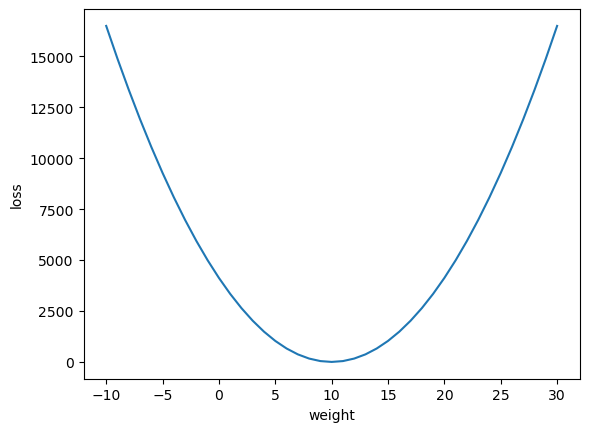

In [10]:
# w에 따른 오차 그래프 → 아래로 볼록한 2차 곡선(밥그릇) 모양이 나온다
# 곡선의 가장 낮은 지점(오차가 최소인 곳)의 w가 우리가 찾는 최적의 가중치!
plt.plot(w_arr, mse_list)
plt.xlabel("weight")
plt.ylabel("loss")

plt.show()

### 2-1. Gradient Descent(경사하강법)을 통한 최적의 w값 도출

위처럼 모든 w를 다 넣어보는 건 비효율적이다.
**경사하강법**은 곡선의 **기울기(경사)를 따라 조금씩 내려가면서** 최저점을 찾아간다.

> 🚶 **학습률(eta0)** = 한 걸음의 **보폭**
> - 너무 크면 → 최저점을 지나쳐 버린다 (발산)
> - 너무 작으면 → 도착까지 너무 오래 걸린다


In [11]:
from sklearn.linear_model import SGDRegressor   # 확률적경사하강법이 적용된 모델

In [12]:
# 경사하강법이 적용된 회귀 모델 정의 (하이퍼파라미터 설정)
sgd_rg = SGDRegressor(
    eta0 = 0.01,    # 학습률 (보폭)
    max_iter = 5000,    # w값의 업데이트 횟수를 최대 5000번까지
    verbose = 1    # 학습 되는 진행 과정을 출력해라
)

In [13]:
# 학습 → verbose=1 이므로 반복(Epoch)마다 줄어드는 오차가 출력된다
sgd_rg.fit(data[["시간"]], data[["성적"]])

-- Epoch 1
Norm: 9.05, NNZs: 1, Bias: 1.060307, T: 4, Avg. loss: 1037.224540
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 9.65, NNZs: 1, Bias: 1.134415, T: 8, Avg. loss: 7.608487
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 9.79, NNZs: 1, Bias: 1.150015, T: 12, Avg. loss: 0.610289
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 9.82, NNZs: 1, Bias: 1.149685, T: 16, Avg. loss: 0.192755
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 9.83, NNZs: 1, Bias: 1.146793, T: 20, Avg. loss: 0.149508
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 9.85, NNZs: 1, Bias: 1.144052, T: 24, Avg. loss: 0.139426
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 9.84, NNZs: 1, Bias: 1.139646, T: 28, Avg. loss: 0.137590
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 9.84, NNZs: 1, Bias: 1.135670, T: 32, Avg. loss: 0.137413
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 9.85, NNZs: 1, Bias: 1.132636, T: 36, Avg. loss: 0.134869
Total training time: 0.00 seconds.
-- Epoch 

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,5000
,tol,0.001
,shuffle,True
,verbose,1
,epsilon,0.1
,random_state,None


In [14]:
# 경사하강법이 한 걸음씩 내려가며 찾아낸 w와 b
# (위 LinearRegression이 한 번에 계산한 값과 비교해보기)
sgd_rg.coef_, sgd_rg.intercept_

(array([9.85608274]), array([1.04236436]))

In [15]:
# 분류 모델의 score와는 다름!
# 분류에서는 얼마나 맞췄나(Accuracy)
# 회귀에서는 평가지표로 (오차값: 예측값과 실제값의 차이)
# R^2: 0~1사이, 1에 가까울수록 데이터의 분포를 잘 이해하는 모델이다!
sgd_rg.score(data[["시간"]], data[["성적"]])

0.9997365041447173

## 3. Boston House Data로 집값 예측

특정 기간의 보스턴 지역 거주지 데이터를 바탕으로 **주택 가격(MEDV)** 을 예측한다.
정답이 '가격'이라는 숫자이므로 → **회귀 문제**


In [16]:
## 주택 가격 → 분류가 아닌 회귀 문제로 접근
import seaborn as sns
from sklearn.model_selection import train_test_split

In [17]:
data = pd.read_csv('./data/boston_house.csv')
data
# CRIM: 지역별 범죄 발생율
# ZN: 25,000평방피트를 초과하는 거주 지역의 비율
# INDUS: 비상업 지역 넓이의 비율
# CHAS: 찰스강에 대한 더미 변수 (1: 강의 경계, 0: 그 외)
# NOX: 일산화질소 농도
# RM: 거주 가능한 방 수
# AGE: 1940년 이전에 건축된 소유 주택의 비율
# DIS: 5개 주요 고용센터까지의 가중 거리
# RAD: 고속도로 접근 용이도
# TAX: 10,000달러 당 재산세율
# PTRATION: 지역의 교사와 학생 비율
# B: 지역의 흑인 거주 비율
# LSTAT: 하위 계층의 비율
# MEDV: 본인 소유 주택 가격의 중앙값 (y)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [18]:
# 컬럼별 개수 / 자료형(Dtype) / 결측치 확인
# → 506개 행이 모두 채워져 있고 전부 숫자형이라 별도의 전처리가 필요 없다
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### 3-1. 전처리 불필요 → EDA 진행

**상관계수(correlation)** 로 어떤 Feature가 집값(MEDV)과 관련이 깊은지 살펴본다.
(−1 ~ 1 범위, **절댓값이 클수록** 연관도가 높다)


In [19]:
# Feature들 사이의 상관관계 분석 (숫자가 클수록 함께 움직인다는 뜻)
data.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


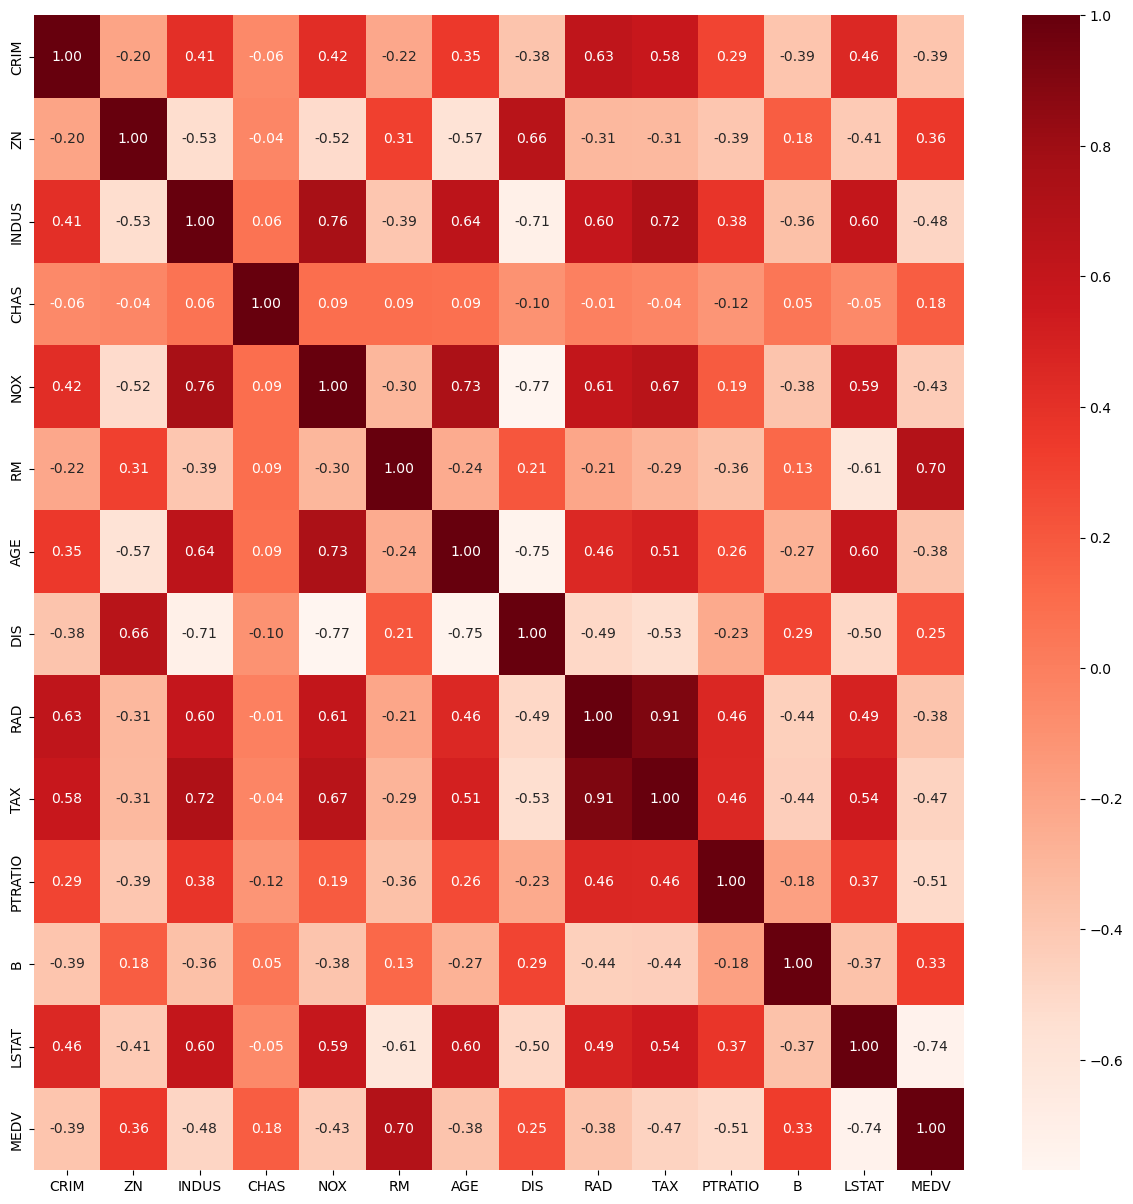

In [20]:
plt.figure(figsize=(15,15))

# 상관관계(correlation) 히트맵
sns.heatmap(data=data.corr(),
           annot=True,         # annotation: 각 셀의 값을 표시
           fmt='.2f',          # fmt: 소수점 몇째자리까지 표현
            cmap = 'Reds'
);
# MEDV(y)값에 높은 상관도를 보이는 Feature는 RM, LSTAT

### 3-2. X · y 정의 후 학습/평가 데이터 분리

In [21]:
# X,y 정의
y = data['MEDV']            # 정답(label) : 집값
X = data.loc[:,:'LSTAT']    # 문제(feature) : MEDV를 뺀 나머지 13개 컬럼

In [22]:
# 학습용 7 : 평가용 3 으로 분리
# random_state : 섞는 기준값 고정 → 실행할 때마다 같은 결과가 나오도록
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size = 0.3,
                                                   random_state = 5
                                                   )

In [23]:
# 분리된 데이터 크기 확인 (행 개수, 열 개수)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(354, 13)
(152, 13)
(354,)
(152,)


## 4. Linear Regression Model 적용

**모델 정의 → 학습 → 예측 → 평가** 순서로 진행한다.


In [24]:
# 선형회귀 모델
from sklearn.linear_model import LinearRegression

# 회귀 평가지표 MSE
from sklearn.metrics import mean_squared_error

In [25]:
# 모델 정의 → 학습
linear = LinearRegression()
linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# w값 (Feature(특성) 13개에 대해서 각각으로 총 13개 출력)
# y = w1x1 + w2x2 + ...... + w13x13 + b
linear.coef_

array([-1.54486040e-01,  4.13948217e-02, -2.53765225e-02,  7.86055259e-01,
       -1.29365836e+01,  4.03952301e+00, -1.05354914e-02, -1.33498644e+00,
        3.18272501e-01, -1.26427463e-02, -9.77287564e-01,  1.26714702e-02,
       -4.62052176e-01])

In [27]:
np.set_printoptions(suppress=True, precision=4)   # 지수 표기를 억제한다(e-01) 그리고 소수점 제한을 준다

In [28]:
# 지수 표기(e-01)가 사라져서 가중치 값을 읽기 쉬워졌다
linear.coef_

array([ -0.1545,   0.0414,  -0.0254,   0.7861, -12.9366,   4.0395,
        -0.0105,  -1.335 ,   0.3183,  -0.0126,  -0.9773,   0.0127,
        -0.4621])

In [29]:
#### Feature들 사이에 서로 어떤게 연결되어 있는지 눈으로 확인하기 위해서
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear.coef_
})
coef_df

,Feature,Coefficient
0,CRIM,-0.154486
1,ZN,0.041395
2,INDUS,-0.025377
3,CHAS,0.786055
4,NOX,-12.936584
5,RM,4.039523
6,AGE,-0.010535
7,DIS,-1.334986
8,RAD,0.318273
9,TAX,-0.012643


In [30]:
# RM이랑 LSTAT이 가중치가 제일 크게 영향을 주지 않는다!
# NOX가 가중치가 제일 큰데?

# 독립변수에 들어가는 수치의 단위가 다르다 (Scale이 서로 다르다)
# NOX는 일산화질소 농도로 소수점 / Age는 숫자가 크다

In [31]:
# y = wx + b 에서의 b (절편)
linear.intercept_

np.float64(31.730351296497787)

### 4-1. 예측 → 평가 (MSE · RMSE · R²)

> 📌 **train 성능과 test 성능의 차이**를 꼭 함께 본다.
> 차이가 크게 벌어지면 → **과대적합(Overfitting)**, 즉 훈련 데이터만 외운 모델이다.


In [33]:
# 예측 (학습에 쓴 데이터 / 처음 보는 데이터 각각)
linear_train = linear.predict(X_train)
linear_test = linear.predict(X_test)

In [34]:
# 예측된 집값들 (실제 y_train 값과 비교해보면 얼마나 비슷한지 감이 온다)
linear_train

array([11.4309, 13.7185, 26.4186, 31.6866, 11.0511, 24.7729, 28.9531,
       32.2259, 15.6178, 30.3854,  9.9983, 34.6405, 25.6395, 20.2432,
       15.5414, 13.036 , 30.4522, 13.2658, 24.4609, 20.5425, 13.6812,
       21.8499, 14.1066, 18.6271, 22.1684, 33.4791, 22.3938, 16.7195,
       30.8946, 38.6076, 26.5084, 25.969 , 15.1705, 15.8474, 35.9205,
       22.7883, 33.553 , 25.2657, 20.8824, 17.1336, 23.4906, 19.8579,
       30.3236, 16.4674, 25.5273, 26.7393, 23.9351, 22.7894, 32.9337,
       18.773 , 30.8384, 28.7822, 13.3372, 32.7834, 27.6637, 19.5787,
       35.5025, 14.3487, 24.9673, 28.3706, 22.3478, 18.7344, 20.9501,
       25.0458, 19.914 , 32.3946, 23.7971, 19.401 ,  7.0189,  5.5508,
       22.3174, 19.6758, 20.9031, 21.4219, 17.661 , 31.3212, 37.6994,
       20.0529, 13.2866, 27.283 , 16.4181, 25.059 , 18.5833, 24.1286,
       14.647 , 20.553 , 13.4972, 22.0413, 27.716 , 22.9651, 17.0856,
       15.406 , 21.3564, 38.8502, 19.8867, 15.169 , 15.1044, 24.6601,
       17.738 , 21.3

In [36]:
# 평가
# MSE(Mean Squared Error) : 오차를 제곱해서 평균 → 값이 작을수록 좋다
train_mse = mean_squared_error(y_train, linear_train)
test_mse = mean_squared_error(y_test, linear_test)
print('train MSE : ', train_mse)
print('test MSE : ', test_mse)
print('train, test MSE 차이 : ', test_mse - train_mse)

train MSE :  19.068341850927222
test MSE :  30.69703770408845
train, test MSE 차이 :  11.62869585316123


In [37]:
# RMSE(Root Mean Squared Error) : MSE에 루트를 씌운 값
# → 제곱하며 뻥튀기된 단위를 원래 단위로 되돌려서 해석이 쉬워진다
train_rmse = train_mse**0.5
test_rmse = test_mse**0.5
print('train RMSE : ', train_rmse)
print('test RMSE : ', test_rmse)
print('train, test RMSE 차이 : ', test_rmse - train_rmse)

train RMSE :  4.366731254717563
test RMSE :  5.54049074578132
train, test RMSE 차이 :  1.1737594910637572


In [39]:
# R2 Score → 1에 가까울수록 좋다
# 0.7 이상 나와야 좋은 모델 / 0.5 이상 나오면 조정 필요
train_R2 = linear.score(X_train, y_train)
test_R2 = linear.score(X_test, y_test)
print('train R2 : ', train_R2)
print('test R2 : ', test_R2)

train R2 :  0.7611598772034454
test R2 :  0.6771696999851706


## 5. 선형회귀 모델 데이터 특성확장 (Feature를 늘린다)

- 선형회귀 모델은 데이터의 분포가 **직선에서 벗어날수록** 예측 정확도가 낮아진다
- 게다가 선형회귀 모델은 **튜닝할 하이퍼파라미터가 없다**

> 💡 그래서 **모델**을 바꾸는 대신 **데이터(특성)** 를 늘려서 성능을 올려본다.
> 기존 13개 컬럼을 서로 곱해(13 × 13) 169개의 새로운 Feature를 만든다.


In [ ]:
# - 선형회귀 모델은 데이터의 분포가 직선의 형태를 많이 벗어나면 벗어날수록 예측 정확도가 낮아진다
# - 추가로, 선형회귀 모델은 튜닝 할 hyper parameter가 없다
# → 그래서 '특성 확장'을 통해 성능 개선을 시도한다

In [40]:
# 원본을 그대로 두기 위해 복사본을 만들어서 컬럼을 추가한다
extended_X_train = X_train.copy()

In [41]:
for col1 in X_train.columns:       # 13번
    for col2 in X_train.columns:   # 13번 더 → 169번
        extended_X_train[col1 + 'x' + col2] = X_train[col1] * X_train[col2]

## 169개의 Feature 추가하기 → 데이터 접근에 성능저하가 올 수 있다.

C:\Users\USER\AppData\Local\Temp\ipykernel_22168\1680907357.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  extended_X_train[col1 + 'x' + col2] = X_train[col1] * X_train[col2]
C:\Users\USER\AppData\Local\Temp\ipykernel_22168\1680907357.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  extended_X_train[col1 + 'x' + col2] = X_train[col1] * X_train[col2]
C:\Users\USER\AppData\Local\Temp\ipykernel_22168\1680907357.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

In [42]:
# 컬럼이 13개 → 182개(13 + 169)로 늘어난 것을 확인
extended_X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,...,LSTATxCHAS,LSTATxNOX,LSTATxRM,LSTATxAGE,LSTATxDIS,LSTATxRAD,LSTATxTAX,LSTATxPTRATIO,LSTATxB,LSTATxLSTAT
445,10.67180,0.0,18.10,0,0.740,6.459,94.8,1.9879,24,666,...,0.0,17.74520,154.88682,2273.304,47.669842,575.52,15970.68,484.396,1032.5788,575.0404
428,7.36711,0.0,18.10,0,0.679,6.193,78.1,1.9356,24,666,...,0.0,14.61208,133.27336,1680.712,41.654112,516.48,14332.32,434.704,2081.6296,463.1104
481,5.70818,0.0,18.10,0,0.532,6.750,74.9,3.3317,24,666,...,0.0,4.11768,52.24500,579.726,25.787358,185.76,5154.84,156.348,3042.3618,59.9076
55,0.01311,90.0,1.22,0,0.403,7.249,21.9,8.6966,5,226,...,0.0,1.93843,34.86769,105.339,41.830646,24.05,1087.06,86.099,1904.4233,23.1361
488,0.15086,0.0,27.74,0,0.609,5.454,92.7,1.8209,4,711,...,0.0,10.99854,98.49924,1674.162,32.885454,72.24,12840.66,363.006,7135.3254,326.1636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,5.69175,0.0,18.10,0,0.583,6.114,79.8,3.5459,24,666,...,0.0,8.73334,91.58772,1195.404,53.117582,359.52,9976.68,302.596,5882.3464,224.4004
189,0.08370,45.0,3.44,0,0.437,7.185,38.9,4.5667,5,398,...,0.0,2.35543,38.72715,209.671,24.614513,26.95,2145.22,81.928,2139.2910,29.0521
495,0.17899,0.0,9.69,0,0.585,5.670,28.8,2.7986,6,391,...,0.0,10.29600,99.79200,506.880,49.255360,105.60,6881.60,337.920,6921.9040,309.7600
206,0.22969,0.0,10.59,0,0.489,6.326,52.5,4.3549,4,277,...,0.0,5.36433,69.39622,575.925,47.773253,43.88,3038.69,204.042,4331.7239,120.3409


In [43]:
###### 참고용 / 경고 표시 안뜨는 방법
import warnings
warnings.filterwarnings('ignore')

In [44]:
# test 데이터에도 train과 '똑같은 방식'으로 특성을 확장해줘야 한다
extended_X_test = X_test.copy()
for col1 in X_test.columns:
    for col2 in X_test.columns:
        extended_X_test[col1 + 'x' + col2] = X_test[col1] * X_test[col2]

In [45]:
# 특성을 늘린 새로운 데이터로 다시 학습
linear2 = LinearRegression()
linear2.fit(extended_X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
# train R2 → 확 올라갔다 (훈련 데이터는 아주 잘 맞힌다)
linear2.score(extended_X_train, y_train)

0.9332471683804469

In [48]:
# test R2 → train보다 많이 떨어진다 = 과대적합(Overfitting) 발생!
linear2.score(extended_X_test, y_test)

0.8093536758663213

## 6. Lasso, Ridge를 통한 Linear Regression 규제

과대적합을 잡기 위해 **규제(Regularization)** 를 건다.
= 가중치(w)가 너무 커지지 못하도록 **모델에 제약을 주는 것**

| 모델 | 규제 방식 | 특징 |
|---|---|---|
| **Lasso** (L1) | 필요 없는 w를 **0으로 만들어 버린다** | 중요한 Feature만 골라내는 효과 |
| **Ridge** (L2) | w를 **0에 가깝게 줄인다** (0은 안 됨) | 전체적으로 부드럽게 규제 |

> `alpha` : 규제의 세기. **커질수록 규제가 강해져** 훈련 성능은 내려가지만 과대적합이 줄어든다.


### 6-1. Lasso (L1 규제)

In [53]:
from sklearn.linear_model import Lasso

# alpha = 1(default): alpha가 커질수록 규제가 강해져서 과대적합은 줄어들고 오차가 커진다
lasso = Lasso()

lasso.fit(extended_X_train, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [55]:
# Lasso의 특징: 중요도가 낮은 특성(Feature)의 가중치(w)를 0으로 만들어요
# coef_ 0이 아닌 값들을 보면 어떤 특성(Feature) 사용했는지 알수가 있다.
lasso.coef_ != 0

array([False, False, False, False, False, False, False, False, False,
        True, False, False, False,  True, False, False, False, False,
       False,  True, False,  True,  True, False,  True,  True, False,
        True,  True, False, False,  True,  True,  True, False,  True,
       False,  True, False, False, False,  True, False, False, False,
        True, False,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False,  True, False,
        True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False,  True, False,
       False, False, False,  True, False, False,  True, False,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True, False, False,
       False, False,  True,  True, False,  True, False,  True, False,
        True,  True,  True, False, False, False,  True, False,  True,
        True,  True,

In [56]:
# 182개의 특성 중 94개만을 사용한다
sum(lasso.coef_ != 0)

np.int64(94)

In [58]:
# train R2 (규제가 없던 linear2보다는 낮아졌다)
lasso.score(extended_X_train, y_train)

0.8804239058511475

In [59]:
# test R2 → train과의 차이가 줄었다 = 선형회귀 모델에 비해 과대적합(Overfitting)이 줄어들었다
lasso.score(extended_X_test, y_test)

0.839088093930064

### 6-2. Ridge (L2 규제)

In [62]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha = 1)     # alpha : 규제의 세기 (클수록 강한 규제)
ridge.fit(extended_X_train, y_train)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [63]:
# train R2
ridge.score(extended_X_train, y_train)

0.9290610763449729

In [64]:
# test R2
ridge.score(extended_X_test, y_test)

0.8125837987006228

In [65]:
# alpha = 1 일 때는, lasso가 ridge보다 더 과대적합 해소에 적합하다

### 6-3. alpha 튜닝 — 어느 정도로 규제해야 할까?

`alpha`를 0.001 ~ 100 까지 바꿔가며 **train / test RMSE**를 그려본다.

> 🔎 **읽는 법** : 두 선이 **가장 가까워지면서 test 오차가 낮은 지점**이 좋은 alpha다.
> (두 선이 벌어져 있으면 과대적합, 둘 다 높으면 과소적합)


In [66]:
# Ridge, Lasso가 둘다 공통의 hyperparameter인 alpha를 가지고 있다.
# 하이퍼 파라미터 튜닝(alpha)
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
# RMSE 값을 넣어줄 빈 리스트
lasso_train_list = []
lasso_test_list = []

for i in alpha_list:
    lasso2 = Lasso(alpha = i)
    lasso2.fit(extended_X_train, y_train)

    # train RMSE
    lasso2_train_pred = lasso2.predict(extended_X_train)
    lasso_train_list.append(mean_squared_error(lasso2_train_pred, y_train)**0.5)

    # test RMSE
    lasso2_test_pred = lasso2.predict(extended_X_test)
    lasso_test_list.append(mean_squared_error(lasso2_test_pred, y_test)**0.5)

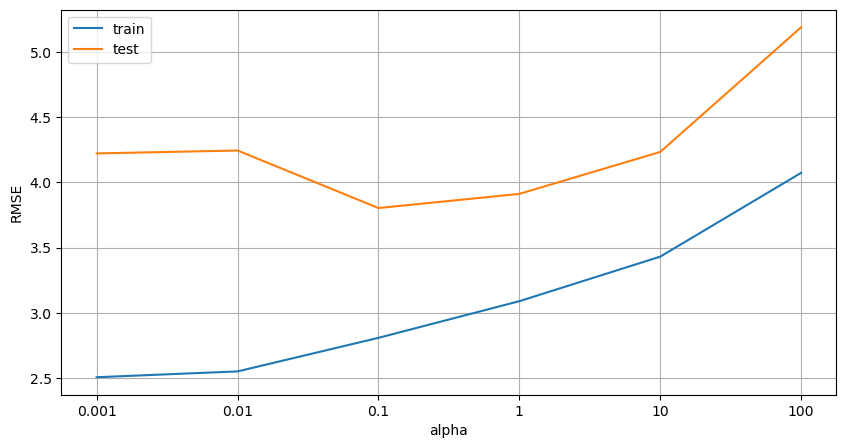

In [67]:
plt.figure(figsize=(10,5))
plt.plot(lasso_train_list, label='train')
plt.plot(lasso_test_list, label='test')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.xticks(np.arange(6), alpha_list)
plt.legend(); plt.grid(); plt.show()

In [68]:
# Ridge도 동일한 방식으로 alpha별 RMSE를 구한다
ridge_train_list = []
ridge_test_list = []

for i in alpha_list:
    ridge2 = Ridge(alpha = i)
    ridge2.fit(extended_X_train, y_train)

    # train RMSE
    ridge2_train_pred = ridge2.predict(extended_X_train)
    ridge_train_list.append(mean_squared_error(ridge2_train_pred, y_train)**0.5)

    # test RMSE
    ridge2_test_pred = ridge2.predict(extended_X_test)
    ridge_test_list.append(mean_squared_error(ridge2_test_pred, y_test)**0.5)

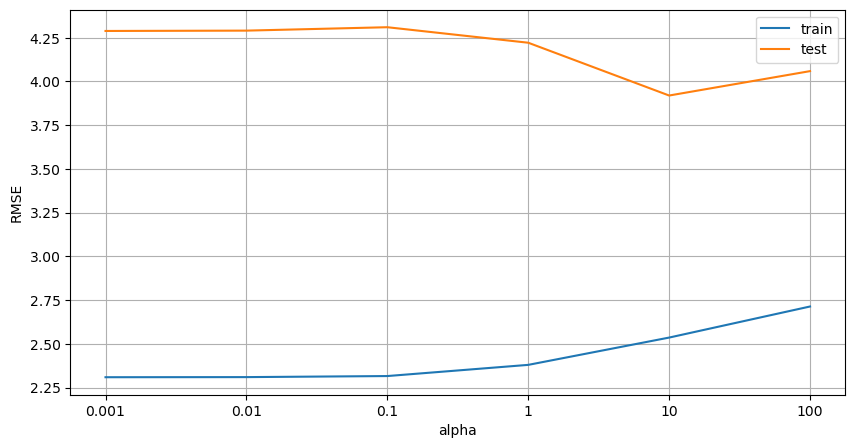

In [69]:
plt.figure(figsize=(10,5))
plt.plot(ridge_train_list, label='train')
plt.plot(ridge_test_list, label='test')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.xticks(np.arange(6), alpha_list)
plt.legend(); plt.grid(); plt.show()

In [70]:
# Lasso 모델과 Ridge 모델 전부 alpha가 10일때 가장 Overfitting(과대 적합) 제어를 잘한다.
# Lasso 모델이 Ridge 모델보다 평균적으로 과대적합 제어를 잘 하지만, Ridge 모델이 RMSE(오차율)이 더 작다
# Boston House 데이터에 대해서는 Ridge가 안정적으로 RMSE가 더 작기 때문에 더 좋은 모델이다!

## 7. 다항회귀(Polynomial Regression)

지금까지 선형회귀는 **직선**만 그렸다.
하지만 특성에 **제곱·세제곱(차수, degree)** 을 더해주면 **곡선**도 그릴 수 있다.

> ⚠️ 차수가 높아질수록 곡선이 자유로워지지만,
> 그만큼 훈련 데이터에 딱 달라붙어 **과대적합**이 되기 쉽다.


### 7-1. 곡선 데이터를 직선 모델로 학습하면?

In [72]:
# 선형회귀로 하면 linear(직선) 형태로만 그래프가 그려진다.
# 하지만 차수를 올리면 곡선도 그릴 수 있다 → 이 실습에서 직접 확인해본다.

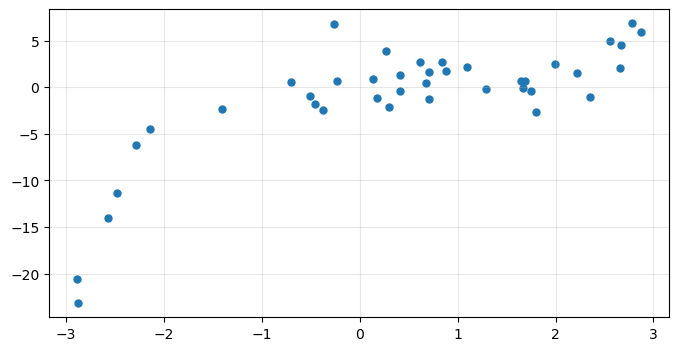

In [75]:
rng = np.random.RandomState(0)
X1 = np.sort(rng.uniform(-3, 3, 40)).reshape(-1, 1)
# -3 ~ 3 사이의 무작위 난수 생성

# .ravel() : 1차원의 벡터로 펼쳐주는 numpy의 기능
# .normal(0, 2.5, 40): 평균 0 normalize 한 숫자 (-2.5 ~ 2.5)
y1 = 0.5*X1.ravel()**3 - X1.ravel()**2 + 2 + rng.normal(0, 2.5, 40)    # 3차원 + (random)noise

X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size = 0.3, random_state = 0)
plt.figure(figsize = (8,4))
plt.scatter(X1, y1, s=25)
plt.grid(alpha=0.3)
plt.show()

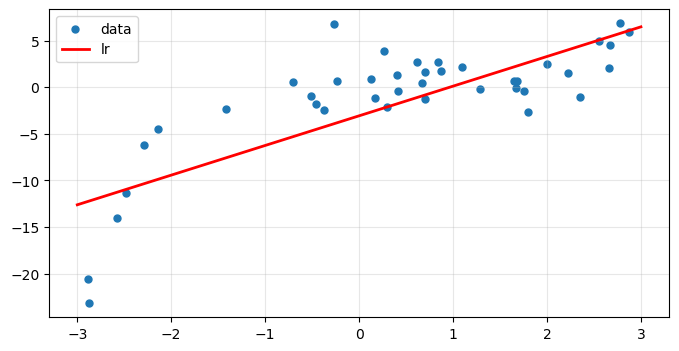

In [77]:
# 곡선 데이터를 직선(선형회귀)으로 맞추면? → 데이터를 전혀 따라가지 못한다
lr = LinearRegression().fit(X_train, y_train)
xs = np.linspace(-3, 3, 200).reshape(-1, 1)

plt.figure(figsize=(8,4))
plt.scatter(X1, y1, s=25, label='data')
plt.plot(xs, lr.predict(xs), 'r-', lw=2, label='lr')
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [78]:
# 직선 모델의 test R2 → 낮게 나온다 (과소적합, Underfitting)
lr.score(X_test, y_test)

-0.5510894102023463

### 7-2. degree(차수)를 바꿔가며 비교

- `PolynomialFeatures(degree=d)` : 특성을 d차까지 곱해서 늘려준다
- `make_pipeline(A, B)` : A → B 를 하나로 묶어 **한 번에 처리**해주는 도구


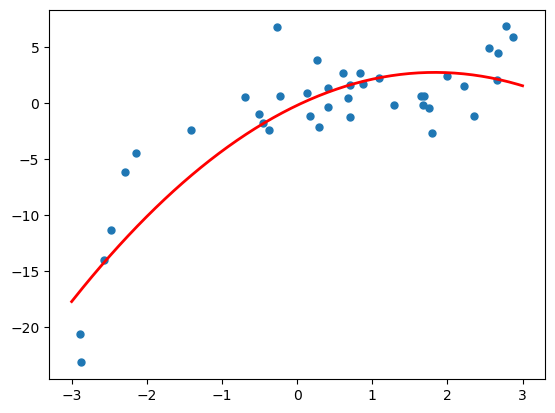

In [80]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# degrees[1] = 2 → 2차 곡선으로 학습해보기
degrees = [1, 2, 3, 5, 10, 20]
model = make_pipeline(PolynomialFeatures(degrees[1]), LinearRegression()).fit(X_train, y_train)
plt.scatter(X1, y1, s=25)
plt.plot(xs, model.predict(xs), 'r-', lw = 2)

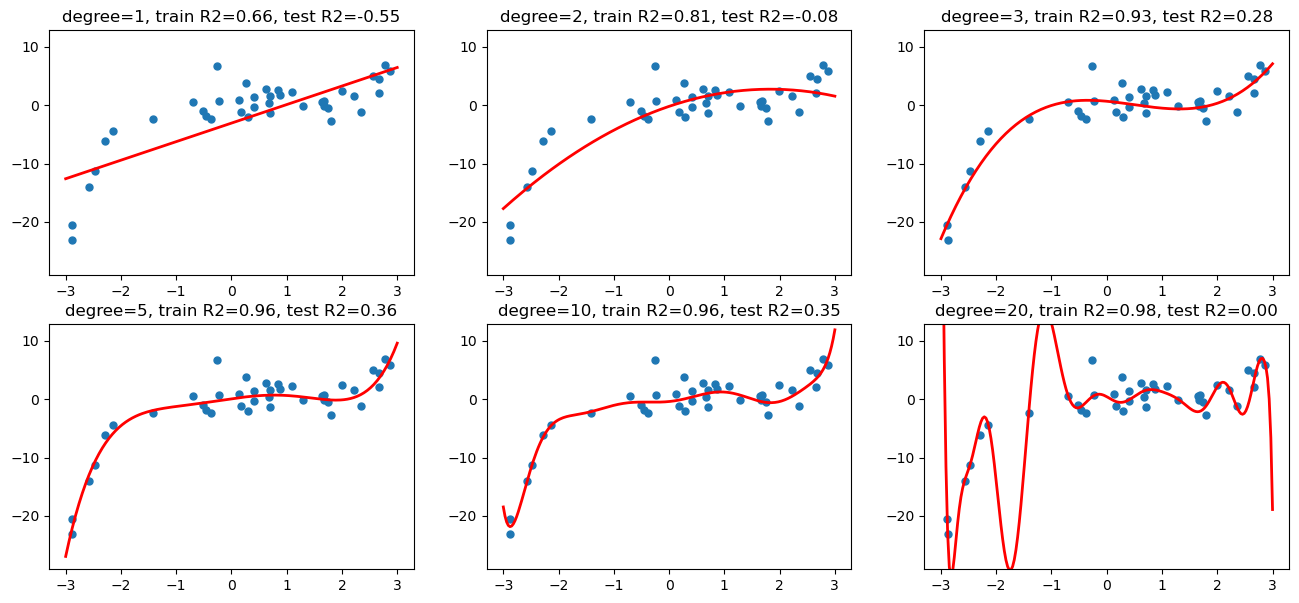

In [83]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 차수를 1 → 20 까지 늘려가며 6개의 그래프를 한 번에 비교
fig, axes = plt.subplots(2, 3, figsize=(16,7))
degrees = [1, 2, 3, 5, 10, 20]

for ax, d in zip(axes.ravel(), degrees):
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).fit(X_train, y_train) ########
    ax.scatter(X1, y1, s=25)
    ax.plot(xs, model.predict(xs), 'r-', lw = 2)
    ax.set_ylim(y1.min()-6, y1.max()+6)
    # 그래프 제목에 train R2와 test R2를 함께 표시 → 과대적합 여부 확인
    ax.set_title(f'degree={d}, train R2={model.score(X_train,y_train):.2f}, test R2={model.score(X_test,y_test):.2f}')
plt.show()

In [ ]:
# degree(차원)를 1~2로 했을때는 회귀 모델을 통해서 예측하는 것보다 평균으로 값을 통일하는게 성능이 더 좋다......
# degree = 3 적절한 차원으로 볼 수 있을거 같다.
# degree = 20 데이터의 점을 억지로 통과하려는 과대적합을 강하게 보인다

### 7-3. 보스턴 집값 예측에 적용해보기

앞에서 **Ridge**가 가장 좋았으므로, `PolynomialFeatures` + `Ridge` 조합으로 실험한다.

> 📏 **StandardScaler(표준화)** 를 먼저 하는 이유
> 컬럼마다 단위가 달라서(NOX는 소수점, TAX는 수백 단위) 그대로 제곱하면 값이 폭발한다.
> 평균 0 · 표준편차 1로 **크기를 맞춰준 뒤** 차수를 올려야 한다.
> ⚠️ Scaler는 **train으로만 fit** 하고, test에는 `transform`만 적용한다.


In [89]:
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('./data/boston_house.csv')
X = data.drop(columns=['MEDV'])     # 정답 컬럼을 뺀 나머지가 문제(X)
y = data['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=8)
sc = StandardScaler().fit(X_train)  # 기준은 train 데이터로만 잡는다
X_train_s, X_test_s = sc.transform(X_train), sc.transform(X_test)

In [92]:
# Ridge가 제일 좋았으니까, Ridge에다가 polynomialfeature
for d in [1,2,3]:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_p = poly.fit_transform(X_train_s)   # train 기준으로 특성 확장
    X_test_p = poly.transform(X_test_s)         # test는 같은 기준을 그대로 적용
    model = Ridge(alpha=1.0).fit(X_train_p, y_train)
    print(X_train_p.shape[1])                   # 확장된 Feature(컬럼) 개수
    print('train R2: ', model.score(X_train_p, y_train))
    print('test R2: ', model.score(X_test_p, y_test))
    print('----------------------------')

13
train R2:  0.7498008494503731
test R2:  0.7077982325362419
----------------------------
104
train R2:  0.933193678098103
test R2:  0.8601787512333304
----------------------------
559
train R2:  0.9874874685679982
test R2:  0.3350271994738575
----------------------------


In [93]:
# Feature(특성)의 개수가 늘어나서 성능이 좋아진거다
# 차수가 3이 되면 차원이(Feature 수가) 559로 확 늘어난다 → 과대적합을 유발한다

# 그래서! 보통 다항특성(Polynomial Feature)를 쓸 땐, 규제와 함께한다(Ridge, Lasso)

In [ ]:
###결론
# Linear Regression 곡선형 모델로 학습 시킬수 있다.
# 차수가 늘어남에 따라 복잡도가 늘어난다 → 과대적합이 될 가능성이 높다!

## 8. ElasticNet (Ridge + Lasso 모두 사용)

Lasso(L1)와 Ridge(L2)를 **섞어서** 쓰는 모델.

- `alpha` : 전체 규제의 세기
- `l1_ratio` : 그중 **Lasso가 차지하는 비율**
  - `0` → Ridge와 동일
  - `1` → Lasso와 동일
  - `0.5` → 반반


In [94]:
from sklearn.linear_model import ElasticNet
# l1_ratio가 0이면 Ridge, 1이면 Lasso만
en = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000).fit(X_train, y_train)
# l1_ration를 (0, 0.5, 1)
en.score(X_test, y_test)

0.6539658848827994

In [98]:
# l1_ratio를 바꿔가며 test 성능 비교 → 이 데이터엔 어떤 조합이 잘 맞는지 확인
for l1 in [0.0, 0.3, 0.5, 0.7, 1.0]:
    en2 = ElasticNet(alpha=0.5, l1_ratio=l1, max_iter=10000).fit(X_train, y_train)
    print('L1 비율: ',l1,'  ', en2.score(X_test, y_test))

L1 비율:  0.0    0.6522021803915807
L1 비율:  0.3    0.6522578744119263
L1 비율:  0.5    0.6539658848827994
L1 비율:  0.7    0.656759035510586
L1 비율:  1.0    0.6647288822227608


## 9. 모델이 "어디서" 틀리는지 — 잔차(Residual) 분석

R²·RMSE는 **얼마나** 틀렸는지만 알려줄 뿐, **어디서 어떻게** 틀렸는지는 알려주지 않는다.
그래서 **잔차(residual)** 를 그려본다. → 실무에서 회귀 모델을 진단하는 표준 방법

> **잔차 = 실제값 − 예측값**
> - 잔차 > 0 → 실제보다 **낮게** 예측 (과소평가)
> - 잔차 < 0 → 실제보다 **높게** 예측 (과대평가)


In [99]:
# R2, RMSE 값은 얼마나 틀렸는지에 대한 성능지표
# 어디서 어떻게 틀렸는지를 모른다 → 잔차(residual)을 살펴본다
# 실무에서 회귀 모델을 진단하는 표준방법

In [100]:
# X_train_s, test_s, y_train, test 그대로 (표준화된 데이터 사용)

lr = LinearRegression().fit(X_train_s, y_train)
pred = lr.predict(X_test_s)
resid = y_test - pred      # 잔차 = 실제값 - 예측값

In [102]:
resid.mean()    # 0에 가까울수록 좋다 (한쪽으로 치우쳐 틀리지 않는다는 뜻)
# 잔차 = 실제값 - 예측값

np.float64(-0.26030584659475936)

### 9-1. 예측값 vs 실제값 산점도

빨간 점선은 `y = x` (완벽하게 맞힌 경우). **점이 선에 붙어 있을수록 잘 맞힌 것**이다.


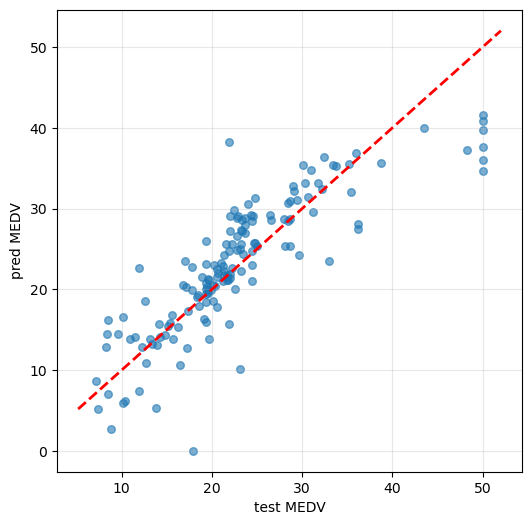

In [105]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.6, s=30)
lim = [y_test.min()-2, y_test.max()+2]
plt.plot(lim, lim, 'r--', lw=2)     # y = x 함수 선 그리기(빨간 점선)
plt.xlabel('test MEDV')
plt.ylabel('pred MEDV')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# y = x 함수에 붙어있을수록 잔차가 작다. → Test(정답), Pred(예측) 같을수록 y = x 직선에 붙어 있을 것이다.
# MEDV 값이 높은 구간에선 점들이 대각선 아래로 몰려있다. → 비싼 집에 대해 과소평가한다.

### 9-2. 잔차 플롯 — 잔차에 '패턴'이 보이는가?

잔차는 **아무 패턴 없이 0 근처에 고르게 흩어져 있어야** 정상이다.
패턴이 보인다면 모델이 뭔가를 놓치고 있다는 신호다.


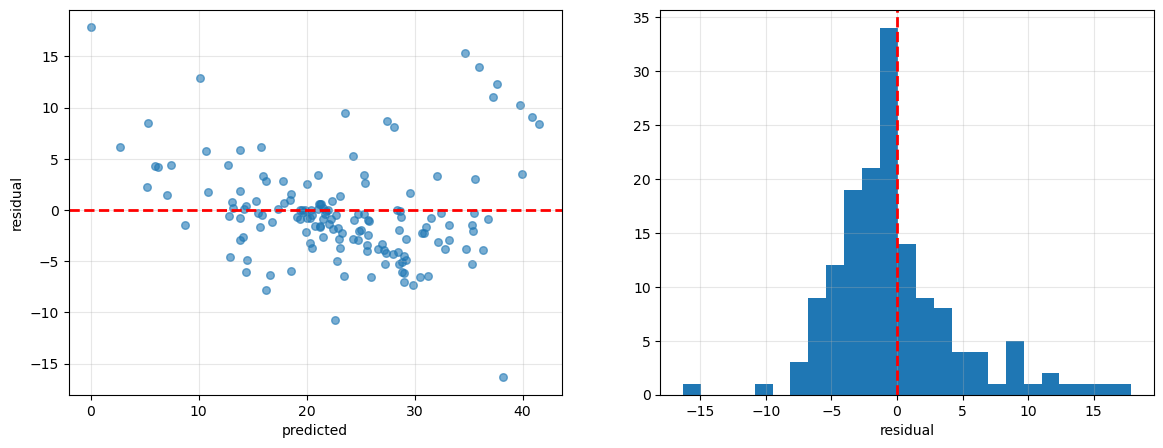

In [107]:
fig, ax = plt.subplots(1,2,figsize=(14,5))

ax[0].scatter(pred, resid, alpha=0.6, s=30)
ax[0].axhline(0,color='r',ls='--',lw=2)
ax[0].set_xlabel('predicted')
ax[0].set_ylabel('residual')
ax[0].grid(alpha=0.3)

ax[1].hist(resid, bins=25)
ax[1].axvline(0,color='r',ls='--',lw=2)
ax[1].set_xlabel('residual')
ax[1].grid(alpha=0.3)

plt.show()

In [ ]:
# 잔차가 곡선을 그린다. → 선형모델에 적합하지 않은 데이터!(다른 모델을 써야된다.) 다항, 비선형
# 예측값이 커질수록 잔차가 부채꼴로 퍼진다. → 분산이 일정하지 않다.
# 잔차 분포가 한쪽으로 치우쳐 있다. → 타겟을 변환해라

### 9-3. 가장 많이 틀린 데이터 확인

In [109]:
# 가장 많이 틀린것에 대한 분석
temp_df = pd.DataFrame({'actual':y_test.values, 'predicted':pred.round(2), 'residual': resid.values.round(2)})
temp_df['abs_err'] = temp_df['residual'].abs()
temp_df.sort_values('abs_err', ascending=False).head()

,actual,predicted,residual,abs_err
102,17.9,0.04,17.86,17.86
2,21.9,38.22,-16.32,16.32
9,50.0,34.66,15.34,15.34
42,50.0,36.00,14.00,14.00
137,23.1,10.16,12.94,12.94


### 9-4. 타겟 로그 변환 — 꼬리가 긴 분포 다루기

집값·소득·인구 같은 데이터는 **최솟값은 0으로 막혀 있지만 최댓값은 열려 있다.**
→ 작은 값에 데이터가 몰리고, 큰 값 쪽으로 **긴 꼬리**가 생긴다.

> 이럴 때 `log`를 씌우면 큰 값들이 촘촘하게 압축되어 **분포가 종 모양에 가까워진다.**
> - `np.log1p(y)` : log(1+y) → y가 0이어도 계산 가능
> - `np.expm1()` : 예측 후 **원래 단위로 되돌리는** 역변환 (꼭 해줘야 한다!)


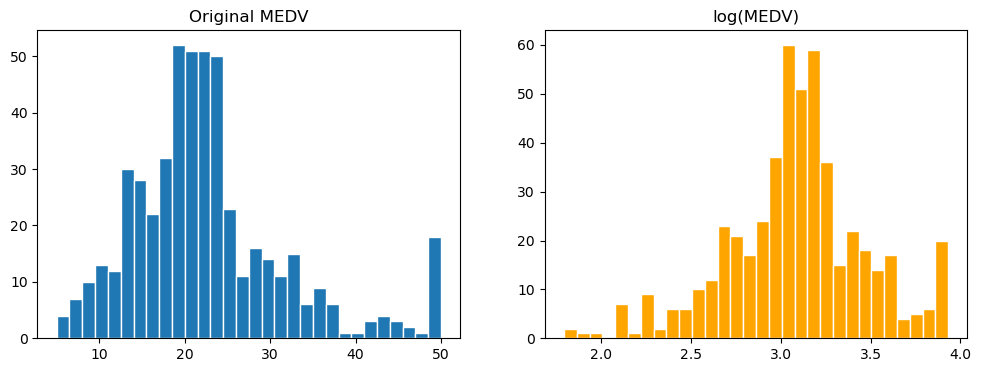

In [111]:
# 타겟의 오른쪽 값의 꼬리가 길(?) 경우 해결 방법 예시
    ####### 집값, 소득, 인구 등과 같은 데이터는 min 제한 "0"이 있지만 max 제한이 없다.
    ####### 작은 값 쪽엔 상대적으로 값들이 몰릴수 있지만, 큰 값 쪽으론 데이터가 많이 없고 꼬리가 길게 형성될 수 있다.
# → 큰 값들이 서로 멀리 떨어져 있는걸 억제해주는 log를 씌워서 해결할 수 있다.

fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].hist(y, bins=30, edgecolor='white')
ax[0].set_title('Original MEDV')

ax[1].hist(np.log1p(y), bins=30, edgecolor='white',color='orange')
ax[1].set_title('log(MEDV)')
plt.show()

In [113]:
from sklearn.metrics import r2_score

# 정답(y)에 log를 씌워서 학습 → 예측 후 expm1로 원래 단위(집값)로 되돌린다
lr_log = LinearRegression().fit(X_train_s, np.log1p(y_train))
pred_log = np.expm1(lr_log.predict(X_test_s))

# 로그 변환 전 vs 후 성능 비교
print('Original R2: ', round(r2_score(y_test, pred),4), 'RMSE: ',round(mean_squared_error(y_test, pred)**0.5,4))
print('Log R2: ', round(r2_score(y_test, pred_log),4), 'RMSE: ',round(mean_squared_error(y_test, pred_log)**0.5,4))

Original R2:  0.7081 RMSE:  4.8699
Log R2:  0.7704 RMSE:  4.3192


## ✅ 오늘 배운 내용 정리

| 구분 | 모델 / 기법 | 핵심 요약 |
|---|---|---|
| 기본 | `LinearRegression` | 데이터를 가장 잘 지나가는 직선 `y = wx + b` 를 찾는다. 하이퍼파라미터 없음 |
| 학습 원리 | `SGDRegressor` | 경사하강법으로 오차가 최소인 w를 조금씩 찾아간다 (`eta0` = 보폭) |
| 성능 개선 | 특성 확장 | Feature를 곱해서 늘린다 → 성능은 오르지만 **과대적합** 위험 |
| 규제 | `Lasso` (L1) | 필요 없는 w를 **0으로** 만든다 → 중요 Feature 선택 효과 |
| 규제 | `Ridge` (L2) | w를 **0에 가깝게** 줄인다 → 보스턴 데이터에선 Ridge가 더 좋았다 |
| 규제 | `ElasticNet` | Lasso + Ridge 혼합 (`l1_ratio`로 비율 조절) |
| 곡선 | `PolynomialFeatures` | 차수를 올려 곡선을 표현. **차수 ↑ = 복잡도 ↑ = 과대적합 ↑** |
| 진단 | 잔차 분석 | R²·RMSE로 못 보는 **"어디서 틀렸는지"** 를 그래프로 확인 |

**기억할 포인트**
1. **train과 test 성능을 항상 같이 본다.** 차이가 크면 과대적합.
2. 다항 특성을 쓸 땐 **반드시 규제(Ridge/Lasso)와 함께** 쓴다.
3. 단위가 다른 Feature를 다룰 땐 **StandardScaler로 스케일을 맞춘다.**
   (Scaler·PolynomialFeatures 모두 **train으로만 `fit`**, test엔 `transform`만!)
4. 잔차에 **패턴이 보이면** 모델·데이터를 손봐야 한다는 신호다.
